
# 1) Intro — Multi-Agent Nutritionist (Two Models)

This workshop uses **two cooperating agents**:

- **Consultant (Medical Expert) — `Qwen/Qwen3-30B-A3B-Instruct-2507-FP8`**  
  Acts as the *brain* for our medical expert agent. It has access to a **local OpenNutrition DB** (ingredient/nutrition data + potential health warnings).  
  It **assesses the ingredients** of a provided food item and returns an expert analysis plus **healthier alternatives**.

- **Orchestrator (Vision + Retrieval) — `Qwen/Qwen3-VL-30B-A3B-Instruct-FP8`**  
  Accepts **images (labels/barcodes)** or **text**. Uses **OpenFoodFacts (OFF) API** tools to gather ingredients.  
  If OFF fails, it uses **EXA via MCP** as a fallback web search.  
  Finally, it **consults the expert agent** and produces a full analysis and suggested **healthier alternatives**.
  

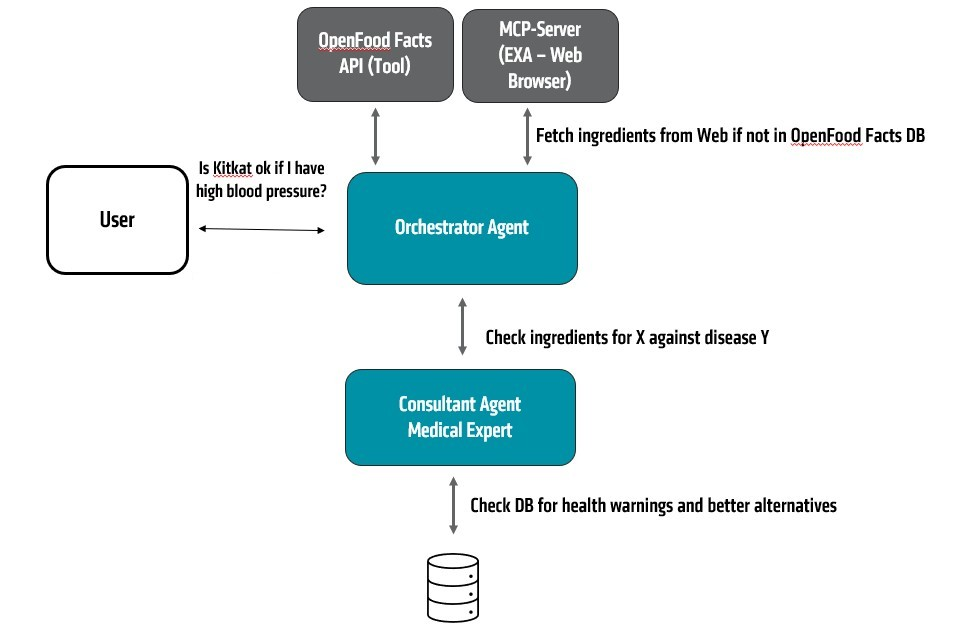


# 2) Flow, Goals, and Agenda

## Flow (High Level)
1. Orchestrator receives input (image/barcode/text) for a snack/food.
2. Orchestrator looks up **ingredients** using **OFF API**; if not found, uses **EXA (MCP)**.
3. Orchestrator passes clean ingredients (or product name) to **Consultant**.
4. Consultant evaluates risks, flags concerns, and proposes **healthier alternatives**.
5. Orchestrator returns a concise, user-friendly **verdict + reasons + alternatives**.

## What You Will Build
- A **Vision-capable Orchestrator agent** (Qwen VL) with tools for **OFF** and **EXA (MCP)**.
- A **Consultant agent** (Qwen 30B text) backed by a **local OpenNutrition DB** toolset.
- The **glue** that lets the Orchestrator consult the Consultant automatically.

## What You Will Learn
- Running **open-weights** models with **vLLM** and **tool calling**.
- Turning LLMs into **agents** using **Google ADK**.
- Turning a **local DB** into a **callable tool** for an AI agent.
- Turning an **external API** (OpenFoodFacts) into a **callable tool**.
- Connecting a **web browser** using **MCP** with **EXA**.
- Wiring up **two agents to collaborate** on one task.

## Agenda (You’ll fill in the code cells)
1. Pre-reqs
2. Install dependencies & imports
3. Verify model endpoints
4. Smoke test the **Consultant** model
5. Build **Consultant** agent + tools (local DB)
6. Build **Orchestrator** agent + tools (OFF + EXA fallback)
7. Glue: Orchestrator calls Consultant
8. E2E examples



# 3) Pre-reqs: Running Two Models with vLLM

Today, we will running our workshop on 1 AMD MI300X GPU, powered by ROCm. 
You will launch **two** model servers in separate terminals:

- **Consultant**: `Qwen/Qwen3-30B-A3B-Instruct-2507-FP8` on **:9000**  
- **Orchestrator**: `Qwen/Qwen3-VL-30B-A3B-Instruct-FP8` on **:9001**

> <span style="color: red;">Tip: Start them **sequentially** to avoid OOM.</span>

Start both model endpoints in **separate terminals** so the Orchestrator and Consultant are available.

### Consultant (`Qwen/Qwen3-30B-A3B-Instruct-2507-FP8`) on port **9000**




```bash
VLLM_ATTENTION_BACKEND=TORCH_SDPA \
VLLM_USE_TRITON_FLASH_ATTN=0 \
vllm serve Qwen/Qwen3-30B-A3B-Instruct-2507-FP8 \
  --port 9000 \
  --enable-auto-tool-choice \
  --tool-call-parser hermes \
  --trust-remote-code \
  --gpu-memory_utilization 0.45
```



### Orchestrator (`Qwen/Qwen3-VL-30B-A3B-Instruct-FP8`) on port **9001**
```bash
VLLM_USE_TRITON_FLASH_ATTN=0 \
vllm serve Qwen/Qwen3-VL-30B-A3B-Instruct-FP8 \
  --port 9001 \
  --enable-auto-tool-choice \
  --tool-call-parser hermes \
  --trust-remote-code \
  --gpu-memory_utilization 0.45
```



# 4) Install Pre-reqs and Imports

Let's installs all the libraries, then import what you need. 
Note: The workshop docker instance you are using is already pre-configured with all the necessary packages. Key Python packages installed are `google-adk[extensions]` and `mlflow` (for profiling our Agentic AI application). 

In [1]:
import httpx
import time
import os

# ── Local/project modules ──────────────────────────────────────────────────────
from tools_nutrition_local import reload_tsv, lookup_by_name_local 

# ── Init ───────────────────────────────────────────────────────────────────────
reload_tsv("./datasets/opennutrition_foods.tsv")
print("Nutrition TSV loaded/reloaded for consultant.")

import warnings
# Ignore all user warnings originating from the google.adk module
warnings.filterwarnings("ignore", category=UserWarning, module="google*")
warnings.filterwarnings("ignore", message=".*Pydantic serializer warnings.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="coroutine '.*' was never awaited")

Nutrition TSV loaded/reloaded for consultant.



# 5) Verify Model Endpoints

Create a small helper that hits `/v1/models` for both servers.  
Confirm:
- **Qwen/Qwen3-30B-A3B-Instruct-2507-FP8:9000** — Consultant (text)
- **Qwen/Qwen3-VL-30B-A3B-Instruct-FP8:9001** — Orchestrator (vision)


In [2]:
def check_endpoint(base_url: str) -> None:
    try:
        r = httpx.get(f"{base_url}/models", timeout=10.0)
        r.raise_for_status()
        models = r.json()
        print(f"[OK] {base_url} reachable. Models:", models.get("data", []) or models)
    except Exception as e:
        print(f"[WARN] Could not reach {base_url}: {e}")

check_endpoint("http://localhost:9000/v1")  # Consultant
check_endpoint("http://localhost:9001/v1")  # Orchestrator

[OK] http://localhost:9000/v1 reachable. Models: [{'id': 'Qwen/Qwen3-30B-A3B-Instruct-2507-FP8', 'object': 'model', 'created': 1771947814, 'owned_by': 'vllm', 'root': 'Qwen/Qwen3-30B-A3B-Instruct-2507-FP8', 'parent': None, 'max_model_len': 262144, 'permission': [{'id': 'modelperm-91825db0aa97e37e', 'object': 'model_permission', 'created': 1771947814, 'allow_create_engine': False, 'allow_sampling': True, 'allow_logprobs': True, 'allow_search_indices': False, 'allow_view': True, 'allow_fine_tuning': False, 'organization': '*', 'group': None, 'is_blocking': False}]}]
[OK] http://localhost:9001/v1 reachable. Models: [{'id': 'Qwen/Qwen3-VL-30B-A3B-Instruct-FP8', 'object': 'model', 'created': 1771947814, 'owned_by': 'vllm', 'root': 'Qwen/Qwen3-VL-30B-A3B-Instruct-FP8', 'parent': None, 'max_model_len': 262144, 'permission': [{'id': 'modelperm-94562dcc1f5cdc6c', 'object': 'model_permission', 'created': 1771947814, 'allow_create_engine': False, 'allow_sampling': True, 'allow_logprobs': True, 'a

# 6) Build the Consultant Agent with Google ADK

Use **Google ADK** to turn the text model (`Qwen/Qwen3-30B-A3B-Instruct-2507-FP8` on :9000) into a structured **Consultant agent**.

**Goals**
- Define a concise **system prompt** (safety-first; JSON-only outputs).
- Create the agent bound to the **consultant endpoint**.
- Provide a tiny **async runner** helper to test the agent with a simple ingredient list.

**Hints**
- Keep the system prompt minimal and enforce JSON shape.
- Use short reasons (<= 12 words) for readability.
- Don’t browse in this agent; it relies on local DB/tooling and general nutrition knowledge.


In [3]:
from google.adk.agents import Agent
from tools_nutrition_local import reload_tsv, lookup_by_name_local
from google.adk.models.lite_llm import LiteLlm

# Tool definition
def local_lookup_by_name(name: str, top_k: int = 5):
    """Lookup product by name (uses name + alternate_names)."""
    res = lookup_by_name_local(name, top_k=top_k)
    return res if res else [{"status": "not_found"}]


nutritionist_agent = Agent(
    model=LiteLlm(
        model=f"hosted_vllm/Qwen/Qwen3-30B-A3B-Instruct-2507-FP8",
        base_url=f"http://localhost:9000/v1",
    ),
    name='nutritionist_agent',
    description='A helpful assistant for user questions.',
    instruction="""
                You are a **Nutrition Consultant AI**.

                ### 1. Role
                Evaluate food products or ingredient lists for a specific health goal. Recommend healthier alternatives from your tool local_lookup_by_name that taste similar and fit the same product type.

                ### 2. Input
                You will receive either:
                1) a product name, or 2) a list of ingredients, and a goal in {general_health, low_sodium, low_sugar, high_protein}.

                ### 3. Process
                - If a **product name** is provided, use `local_lookup_by_name` to retrieve a record and ingredients; then analyze.
                - If only **ingredients** are provided, analyze using domain knowledge, infer product type(cookie, soup, rice dish, potato chips, etc) and consider alternatives based on type.
                - Find one healthier healther alternative by finding it using `local_lookup_by_name` that is from the same type(i.e if the product is soup, suggest a healther soup).
                - Decide overall: ok | caution | avoid | uncertain. Keep reasons concise.
                ### 4. Rules
                - **Quota:** You are strictly limited to a maximum of 3 total tool calls per request.
                - If the alternative item you suggested is NOT found by `local_lookup_by_name` then keep trying until you find a healthier alternative that is found by this tool.
                
                ### 4. Output (JSON only)
                {
                "product": "string | optional",
                "overall": "ok | caution | avoid | uncertain",
                "reasons": ["<=12 words each"],
                "warnings": ["<=12 words each"],
                "alternatives": [{"name": "string", "reason": "<=10 words"}],
                "notes": ["optional tip"],
                "disclaimer": "Educational only; not medical advice."
                }
                """,
    tools=[local_lookup_by_name],
)

## 7) Let's test our Consultant Agent (aka the Nutritionist Expert)

In **Google ADK**, to manage conversations and execute the agent, we need two more components:

`SessionService`: Responsible for managing conversation history and state for different users and sessions. The `InMemorySessionService` is a simple implementation that stores everything in memory, suitable for testing and simple applications. It keeps track of the messages exchanged. We'll explore state persistence more later sections of this workshop.

`Runner`: The engine that orchestrates the interaction flow. It takes user input, routes it to the appropriate agent, manages calls to the LLM and tools based on the agent's logic, handles session updates via the `SessionService`, and yields events representing the progress of the interaction.

In [4]:
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

app_name="Consultant Nutritionist App"

#create session for the app
session_service = InMemorySessionService()
await session_service.create_session(
            app_name=app_name,
            user_id="user_123",
            session_id="default_session",
        )

# runner for app
runner = Runner(
    app_name=app_name, 
    agent=nutritionist_agent, 
    session_service=session_service
    )
# user query
query = "Cooked rice, Kimchi, Gochujang, Soy sauce, Sesame oil, Garlic...; goal: low_sodium."
user_query = types.Content(role="user", parts=[types.Part.from_text(text=query)])
response = runner.run(new_message=user_query, session_id="default_session", user_id="user_123")
for event in response:
    print(event)

model_version='hosted_vllm/Qwen/Qwen3-30B-A3B-Instruct-2507-FP8' content=Content(
  parts=[
    Part(
      function_call=FunctionCall(
        args={
          'name': 'Kimchi'
        },
        id='chatcmpl-tool-92a6af6039e4df84',
        name='local_lookup_by_name'
      )
    ),
    Part(
      function_call=FunctionCall(
        args={
          'name': 'Soy sauce'
        },
        id='chatcmpl-tool-9e05ab99d22be8a8',
        name='local_lookup_by_name'
      )
    ),
    Part(
      function_call=FunctionCall(
        args={
          'name': 'Gochujang'
        },
        id='chatcmpl-tool-978dfe14ff542e91',
        name='local_lookup_by_name'
      )
    ),
  ],
  role='model'
) grounding_metadata=None partial=False turn_complete=None finish_reason=<FinishReason.STOP: 'STOP'> error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=GenerateContentResponseUsageMetadata(
  cached_content_token_count=0,
  candidates_token_count=72,
  prompt_token_

# 8) Orchestrator (Phase 1) – Ingredient Extractor (no tools yet)

Create a **Vision-capable Orchestrator** agent (`Qwen/Qwen3-VL-30B-A3B-Instruct-FP8` on :9001) **without tools** to start.

**Goals**
- Set a system prompt that **returns only a cleaned ingredient list** when given a product name or image.
- Keep responses brief (<= 5 lines).
- Ask **one clarifying question** if the query is ambiguous.

**Hints**
- This phase helps validate basic I/O with the VLM before wiring tools.
- You can test with text-only queries first.


In [5]:
from google.adk.agents import Agent
from google.adk.models.lite_llm import LiteLlm

ORCHCHESTRATOR_INSTRUCTION_PHASE1 = """
    You are an Ingredient Orchestrator.
    Goal: When the user names a packaged snack, a dish, or provides a picture, return ONLY a cleaned ingredient list (bullets or comma-separated) along with product name. If ambiguous, state one brief assumption.
    Keep response ≤ 5 lines. Educational only; not medical advice.
    """

orchestrator_agent = Agent(
    model=LiteLlm(
        model=f"hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8",
        base_url=f"http://localhost:9001/v1",
        ),
    name='orchestrator_agent',
    instruction=ORCHCHESTRATOR_INSTRUCTION_PHASE1,
    )

## Testing the Orchestrator Agent

In [6]:
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

app_name="Orchestrator Agent Test"

#create session for the app
session_service = InMemorySessionService()
await session_service.create_session(
            app_name=app_name,
            user_id="user_123",
            session_id="default_session",
        )

# runner for app
runner = Runner(
    app_name=app_name, 
    agent=orchestrator_agent, 
    session_service=session_service
    )

user_query = types.Content(
    role="user",
    parts=[types.Part(text="Ingredients for KitKat (USA)?"
    ),]
)

response = runner.run(new_message=user_query, session_id="default_session", user_id="user_123")

for event in response:
    print(event.content)

parts=[Part(
  text="""Product: KitKat (USA)  
Ingredients: Sugar, chocolate (sugar, cocoa butter, chocolate liquor, soy lecithin, vanilla), wheat flour, palm oil, milk, whey, cocoa, corn syrup, baking soda, salt, artificial flavor, soy lecithin.  
*Assumption: Based on standard US KitKat bar (milk chocolate).*"""
)] role='model'


# 9) Enable EXA MCP (Fallback Web Search)

Add **EXA via MCP** as a **toolset** available to the Orchestrator for **ingredient retrieval** when OpenFoodFacts/local-DB info is insufficient.

**Goals**
- Initialize `McpToolset` with your `EXA_API_KEY` (environment variable).
- Attach the EXA toolset to the Orchestrator agent.

**Showcase**
- Demonstrate a case where **EXA** finds a manufacturer or retailer page with a clearer ingredient list than initial guesses.


Let's install necessary packages and set EXA MCP client.

In [7]:
from google.adk.tools.mcp_tool import McpToolset
from google.adk.tools.mcp_tool.mcp_session_manager import StdioConnectionParams, StreamableHTTPServerParams, SseConnectionParams, StreamableHTTPConnectionParams
from mcp import StdioServerParameters

# EXA_API_KEY = os.environ.get("EXA_API_KEY", "a88626b0-3545-49bc-bd5a-8126a47d0b70")
EXA_API_KEY = os.environ.get("EXA_API_KEY", "bb2594cb-b0f6-4a9b-a1bd-0c34b769c249")

exa_tools = []

if EXA_API_KEY:

    #local mcp server for testing
    exa_provider =  McpToolset(
        connection_params=StdioConnectionParams(
            server_params = StdioServerParameters(
                command="npx",
                args=["-y", "mcp-remote", f"https://mcp.exa.ai/mcp?exaApiKey={EXA_API_KEY}"],
                env={"EXA_API_KEY": EXA_API_KEY}
            ),
            timeout=20,
        )
    )

    # # Use Streamable HTTP instead of SSE for modern remote MCP servers
    # exa_provider = McpToolset(
    #     connection_params=StreamableHTTPConnectionParams(
    #         url=f"https://mcp.exa.ai/mcp?exaApiKey={EXA_API_KEY}&tools=web_search_exa",
    #         timeout=20,
    #     )
    # )

    # Load the tools from the provider
    exa_tools = await exa_provider.get_tools()
    print(f"EXA MCP enabled: Loaded {len(exa_tools)} tools.")
    for t in exa_tools:
        print("-", t.name)
else:
    print("EXA MCP disabled (set EXA_API_KEY to enable).")

EXA MCP enabled: Loaded 3 tools.
- web_search_exa
- company_research_exa
- get_code_context_exa


Next, we will update our agent system/instruction prompt and `tools` parameter to use EXA.

In [8]:
ORCHESTRATOR_INSTRUCTION_PHASE1_EXA = """
    You are an Ingredient Orchestrator with tool access.
    
    Hard requirement:
    • ALWAYS use web_search_exa (query: str) to look up current ingredients. Do not answer from memory.
    • Always use the 'text' parameter and limit the characters to 2000 to ensure a fast response.
    • Do not answer until you have called web_search_exa at least once in this turn.
    • Do not fetch more than 3 results at a time to save bandwidth.
    • If a search fails to find ingredients, change your query to be more specific (e.g., search for the manufacturer's product page).
    • NEVER use the exact same search query twice in one turn.
    • If you cannot find the info after 2 attempts, explain what you found and ask the user for clarification.
    
    Goal:
    • When a user names a store bought snack or dish, use web_search_exa to find a reliable ingredient list (manufacturer > major retailer).
    • Then list the ingredients and the name of the snack.
    • Provide a link to the source.
    
    Rules:
    • Keep answers short (≤ 6 lines). No internal JSON/tool dumps.
    """

if exa_tools:
    orchestrator_phase1_agent_exa = Agent(
        model=LiteLlm(
            model=f"hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8",
            base_url=f"http://localhost:9001/v1",
        ),
        name='orchestrator_phase1_agent_exa',
        instruction=ORCHESTRATOR_INSTRUCTION_PHASE1_EXA,
        tools= [*exa_tools] if exa_tools else None,
    )
    print("Orchestrator agent with EXA tools initialized.")
else:
    print("error: EXA tools not available, cannot initialize agent with EXA toolset.")

Orchestrator agent with EXA tools initialized.


Let's try the agent with browsing enabled.

In [9]:
app_name="Orchestrator Agent App"

#create session for the app
session_service = InMemorySessionService()
await session_service.create_session(
            app_name=app_name,
            user_id="user_123",
            session_id="default_123",
        )

# runner for app
runner_1 = Runner(
    app_name=app_name, 
    agent=orchestrator_phase1_agent_exa, 
    session_service=session_service
    )
# user query
query = "Ingredients for KitKat (USA)?"
user_query = types.Content(role="user", parts=[types.Part.from_text(text=query)])
response = runner_1.run(new_message=user_query, session_id="default_123", user_id="user_123")

for event in response: 
    print(f"\nDEBUG EVENT: {event}\n")
    if event.is_final_response() and event.content:
        final_answer = event.content.parts[0].text.strip()
        print("\n🟢 FINAL ANSWER\n", final_answer, "\n")

time.sleep(2)


DEBUG EVENT: model_version='hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8' content=Content(
  parts=[
    Part(
      function_call=FunctionCall(
        args={
          'query': 'KitKat USA ingredients list official manufacturer'
        },
        id='chatcmpl-tool-b518f6e56971d868',
        name='web_search_exa'
      )
    ),
  ],
  role='model'
) grounding_metadata=None partial=False turn_complete=None finish_reason=<FinishReason.STOP: 'STOP'> error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=GenerateContentResponseUsageMetadata(
  cached_content_token_count=0,
  candidates_token_count=28,
  prompt_token_count=1035,
  total_token_count=1063
) live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-6c21d8a8-064e-4b29-ad09-bab1f4cb3bf3' author='orchestrator_phase1_agent_exa' actions=EventActions

# 10) Add OpenFoodFacts (OFF) Tools : Vision Barcode -> Ingredients

Turn the **OFF API** into callable tools for the Orchestrator:
- `off_by_barcode(ean_13: str) -> dict`
- `off_search_by_name(query: str, limit: int = 10) -> list[dict]`

**Goals**
- Register OFF tools on the Orchestrator.
- Show a **vision example**: read a label/barcode from an image, call `off_by_barcode`, and extract **ingredients**.


In [10]:
from typing import Dict, Any
import openfoodfacts

# Let's use the OpenFoodFact API; user-Agent is mandatory
api = openfoodfacts.API(user_agent="IngredientOrchestrator/1.0 (you@example.com)", timeout=30)

def format_results(p: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "barcode": p.get("code"),
        "product_name": p.get("product_name") or p.get("generic_name"),
        "brand": (p.get("brands") or "").split(",")[0].strip() or None,
        "ingredients_text": p.get("ingredients_text"),
        "countries_tags": p.get("countries_tags"),
        "last_modified_t": p.get("last_modified_t"),
        "source": "off",
    }

def off_by_barcode_fn(ean_13: str) -> dict:
    """OpenFoodFacts API: lookup by EAN‑13 barcode."""
    try:
        return api.product.get(ean_13, fields=["code", "product_name", "brands", "ingredients_text", "last_modified_t", "countries_tags"]) or {"status": "not_found"}
    except Exception as e:
        return {"status": "error", "error": str(e)}

def off_search_by_name_fn(query: str, limit: int = 10, retries: int = 3):
    """OpenFoodFacts API: search by name."""
    try: 
        res = api.product.text_search(query, page_size=limit) or [{"status": "not_found"}]
        return [format_results(product) for product in res["products"]]
    except Exception as e:
        return [{"status": "error", "error": str(e)}]

ORCHESTRATOR_INSTRUCTION_EXA_OPENFOODFACTS = """
You are an Ingredient Orchestrator with tool access.

Data tools (in required priority):
1. off_by_barcode_fn(ean_13)  -> FIRST if a 13-digit barcode is present.
2. off_search_by_name_fn(name) -> If no barcode or barcode lookup failed.
3. use web_search_exa(query: str) to look up current ingredients. Do not answer from memory.

Goal:
• When a user names a store bought snack or dish, use web_search_exa to find a reliable ingredient list (manufacturer > major retailer).
• Then list the ingredients and the name of the snack.
• Provide a link to the source.

Rules:
• Keep answers short (≤ 6 lines). No internal JSON/tool dumps.
"""

orchestrator_agent_exa_openfoodfacts = Agent(
    model=LiteLlm(
        model=f"hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8",
        base_url=f"http://localhost:9001/v1",
    ),
    name='orchestrator_agent_exa_openfoodfacts',
    instruction=ORCHESTRATOR_INSTRUCTION_EXA_OPENFOODFACTS,
    tools=[off_by_barcode_fn, off_search_by_name_fn, *exa_tools] if exa_tools else [off_by_barcode_fn, off_search_by_name_fn],
)

We can now try our VLM, by giving it a picture rather than the name or ingredients. Let's start by making sure the picture we are giving it is a relevant picture.

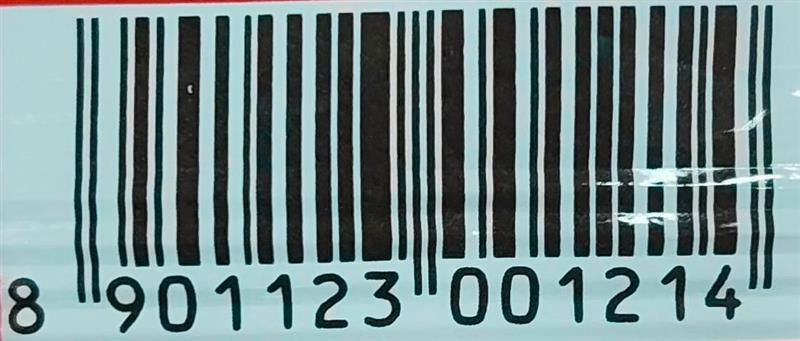

In [11]:
from pathlib import Path #Added recently

img_path = Path("barcode.jpg")
if img_path.exists():
    # Preview the image (fast, no Pillow needed)
    from IPython.display import display, Image as IPImage
    display(IPImage(filename=str(img_path)))  # shows the picture inline
else:
    print("[Info] Sample image not found; skipping image demo.")

Now let's see if our agent can extract the barcode and pass it to its barcode reader tool.

In [12]:
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types
import mimetypes

app_name="Orchestrator Agent EXA App"

#create session for the app
session_service = InMemorySessionService()
await session_service.create_session(
            app_name=app_name,
            user_id="user_123",
            session_id="default_123",
        )

# runner for app
runner_1_exa = Runner(
    app_name=app_name, 
    agent=orchestrator_agent_exa_openfoodfacts, 
    session_service=session_service
    )

# user query
img_path = Path("barcode.jpg")
if img_path.exists():
    mime = mimetypes.guess_type(str(img_path))[0] or "image/jpeg"
    content = [
        types.Part.from_text(
         text="Use the image: extract a barcode (remove all spaces and extra chars); and call off_by_barcode or off_search_by_name to list ingredients."
        ),
        types.Part.from_bytes(
            data=img_path.read_bytes(), 
            mime_type=mime
        )
    ]
    user_query = types.Content(role="user", parts=content)
    response = runner_1_exa.run(new_message=user_query, session_id="default_123", user_id="user_123")

    for event in response: # what are events here? 
        print(f"\nDEBUG EVENT: {event}\n")
        if event.is_final_response() and event.content:
            final_answer = event.content.parts[0].text.strip()
            print("\n🟢 FINAL ANSWER\n", final_answer, "\n")
else:
    print("[Info] Sample image not found; skipping image demo.")



DEBUG EVENT: model_version='hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8' content=Content(
  parts=[
    Part(
      function_call=FunctionCall(
        args={
          'ean_13': '8901123001214'
        },
        id='chatcmpl-tool-9e6e9a92528c2b7f',
        name='off_by_barcode_fn'
      )
    ),
  ],
  role='model'
) grounding_metadata=None partial=False turn_complete=None finish_reason=<FinishReason.STOP: 'STOP'> error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=GenerateContentResponseUsageMetadata(
  cached_content_token_count=0,
  candidates_token_count=38,
  prompt_token_count=1413,
  total_token_count=1451
) live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='e-de853ec5-2429-4fca-88de-9482a6f52973' author='orchestrator_agent_exa_openfoodfacts' actions=EventActions(skip_summarization=None,

# 11) Final Version — Stick Everything Together

Build the final Orchestrator configuration that:
1. Uses **OFF tools** first for barcode/name lookups.
2. Falls back to **EXA (MCP)** only if OFF fails/ambiguous.
3. Calls the **Nutritionist Expert** with either product name or cleaned ingredients. This expert acts as a tool passed to the `root_agent` (Orchestrator)
4. Returns a compact **verdict + 1–3 reasons + 1–2 alternatives**, plus an educational disclaimer.

**Goals**
- Provide a brief **end-to-end** example (text-only and image-based).
- Keep outputs <= 6 lines and avoid leaking raw tool JSON.

A note about **AgentTool**: `AgentTool` is a native wrapper class that allows you to take an entire, fully-configured AI agent, in our case, the Nutritionist Expert, and package it so that another AI agent (in our case, the Orchestrator, can use it exactly like a standard tool. This is the core mechanism for building "Agent-as-a-Tool" multi-agent architectures (like a manager delegating to specialists).

In [13]:
from google.adk.tools.agent_tool import AgentTool

# Really cool ADK Feature of wrapping an expert Agent as a tool.
nutritionist_agent = AgentTool(agent=nutritionist_agent)

root_agent = Agent(
    name="RootOrchestrator",
    model=LiteLlm(
        model=f"hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8",
        base_url=f"http://localhost:9001/v1",
    ),
    instruction=(
        """
        You are an Ingredient Orchestrator with tool access.
        
        Objective:
        Derive an ingredient list  (OFF or EXA) or from an explicit user‑provided list, then call nutritionist_agent with BOTH ingredients (list) and product_name, finally return the final verdict and summary.
        
        Data tools (priority):
        1) off_by_barcode_fn(ean_13) - FIRST if a 13‑digit barcode is present.
        2) off_search_by_name_fn(name) - If no barcode or lookup failed.
        3) web_search_exa(query) - FALLBACK ONLY if OFF fails/ambiguous or if user explicitly asks for freshest data.
        
        RULES:
        - NEVER fabricate ingredients from memory.
        - NEVER output an ingredients list unless it came from tools or the user.
        - If all tools fail, ask the user to paste the ingredients.
        - ALWAYS use nutritionist_agent when you have the ingredients.
        - NEVER suggest your own alternative, always rely on the response from nutritionist_agent
        - NEVER repeat the exact same search query. If 'Product X ingredients' fails, pivot to 'Manufacturer site Product X' or 'Product X nutrition label'.
        - After 2 unsuccessful searches, STOP and report exactly what you found to the user. Do not loop.
        - Always use web_search_exa (text mode, limit 2000 chars, max 3 results).
    
        Goal: Find the ingredient list and source link. Keep answers ≤ 6 lines.
        
        Extraction rules:
        - OFF: prefer ingredients fields; preserve order; trim/dedupe.
        - Web: manufacturer > major retailer > reputable database. Ignore marketing blurbs and storage instructions.
        
        Consultant call:
        - After ingredients are ready, call nutritionist_agent with product_name and ingredients.
        - Do NOT call until ingredients are confirmed.
        
        Ambiguity:
        - If OFF returns multiple variants (country/flavor), ask ONE concise clarifying question.
        
        Final user answer format (≤ 6 lines):
        1) Verdict: OK / Caution / Avoid / Uncertain
        2-4) 1-3 short reasons
        5) Healthier alternative (if available)
        6) Educational only; not medical advice.
        
        **IMPORTANT** Include all the reasoning and actions you took as a summary for the user. Show the results you got from each tool call.
        """ 
    ),
    
    tools=[nutritionist_agent, off_by_barcode_fn, off_search_by_name_fn, *exa_tools] if exa_tools else [nutritionist_agent, off_by_barcode_fn, off_search_by_name_fn]
)

print("Final orchestrator ready.")

Final orchestrator ready.


Time to test our E2E system.

## 12) Observability Setup

### Option 1: Exporting Opentelemetry traces to console and dumping it into a log file

In [14]:
# os.environ["OTEL_SERVICE_NAME"] = "adk-sql-agent"
# os.environ["OTEL_PYTHON_LOGGING_AUTO_INSTRUMENTATION_ENABLED"] = "true"
# os.environ["OTEL_INSTRUMENTATION_GENAI_CAPTURE_MESSAGE_CONTENT"] = "false"
# os.environ["ADK_CAPTURE_MESSAGE_CONTENT_IN_SPANS"] = "false"

# os.environ["OTEL_TRACES_EXPORTER"] = "console"
# os.environ["OTEL_LOGS_EXPORTER"] = "console"
# os.environ["OTEL_METRICS_EXPORTER"] = "none"

# os.environ["OTEL_EXPORTER_OTLP_TRACES_PROTOCOL"] = "none"
# os.environ["OTEL_EXPORTER_OTLP_LOGS_PROTOCOL"] = "none"

In [15]:
# import os
# from opentelemetry import trace
# from opentelemetry.sdk.trace import TracerProvider
# from opentelemetry.sdk.trace.export import BatchSpanProcessor, ConsoleSpanExporter
# from opentelemetry.sdk.resources import Resource, SERVICE_NAME


# TRACE_FILE = "nutritionist_agent_traces_1.jsonl"

# resource = Resource(attributes={
#     SERVICE_NAME: os.environ["OTEL_SERVICE_NAME"]
# })
# provider = TracerProvider(resource=resource)

# trace_file_handle = open(TRACE_FILE, "w", encoding="utf-8")
# file_exporter = ConsoleSpanExporter(out=trace_file_handle)

# span_processor = BatchSpanProcessor(file_exporter)
# provider.add_span_processor(span_processor)
# trace.set_tracer_provider(provider)

# print(f"Tracing enabled. Outputting to: {os.path.abspath(TRACE_FILE)}")

### Option 2: Tracing with MLflow

In [16]:
os.environ["TRACER_ID_NAME"] = "multi_agent_nutrition_app_demo"
enable_mlflow_tracing = True

In [17]:
import subprocess
import time
import os
from IPython.display import HTML, display

# Start MLflow
print("🚀 Starting MLflow server...")

process = subprocess.Popen(
  ['mlflow', 'server', '--backend-store-uri',
   'sqlite:///mlflow.db', '--host', '0.0.0.0', '--port', '5000', '--allowed-hosts', 'dev.amd-ai-academy.com'
  ],
  stdout=subprocess.PIPE,
  stderr=subprocess. PIPE
)
time.sleep(10)

app_url = os.getenv("APP_URL", "")
print(app_url)

🚀 Starting MLflow server...
https://dev.amd-ai-academy.com/app/jupyter-launcher-1771945334-8761/


## 13) Run our Multi-Agent Nutrition Advisor! 

In [18]:
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types
import uuid
import asyncio

APP_NAME="Nutrition Advisor"
USER_NAME="user_123"
SESSION_ID=str(uuid.uuid4())

if enable_mlflow_tracing:
    # Log Trace: MLFlow
    import mlflow
    from opentelemetry import trace
    from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter
    from opentelemetry.sdk.trace import TracerProvider
    from opentelemetry.sdk.trace.export import SimpleSpanProcessor

    # Connect to MLflow
    mlflow.set_tracking_uri(app_url)
    experiment = mlflow.set_experiment(os.getenv("TRACER_ID_NAME"))

    exporter = OTLPSpanExporter(
        endpoint=f"{app_url}/v1/traces",
        headers={"x-mlflow-experiment-id": experiment.experiment_id}
    )

    provider = TracerProvider()
    provider.add_span_processor(SimpleSpanProcessor(exporter))
    trace.set_tracer_provider(provider)

#create session for the app
SESSION_SERVICE = InMemorySessionService()
await SESSION_SERVICE.create_session(
            app_name=APP_NAME,
            user_id=USER_NAME,
            session_id=SESSION_ID,
        )

# runner for app
root_runner = Runner(
    app_name=APP_NAME, 
    agent=root_agent, 
    session_service=SESSION_SERVICE
    )

# user query
query = "Is Kitkat safe to eat for High Blood Pressure?"
# query = "Is Limca safe to drink when I have Fever?"

async def test_run(query):
    user_query = types.Content(role="user", parts=[types.Part.from_text(text=query)])

    # img_path = Path("shared_image.jpg")
    # if img_path.exists():
    #     mime = mimetypes.guess_type(str(img_path))[0] or "image/jpeg"
    #     content = [
    #         types.Part.from_text(
    #          text="Use the image: extract a barcode (remove all spaces and extra chars); and call off_by_barcode or off_search_by_name to list ingredients."
    #         ),
    #         types.Part.from_bytes(
    #             data=img_path.read_bytes(), 
    #             mime_type=mime
    #         )
    #     ]
    #     user_query = types.Content(role="user", parts=content)

    print(f"Debug Session ID: {SESSION_ID}")

    response =  root_runner.run_async(new_message=user_query, session_id=SESSION_ID, user_id=USER_NAME)
    try:
        async for event in response: # what are events here? 
            print(f"\nDEBUG EVENT: {event}\n")
            if event.is_final_response() and event.content:
                final_answer = event.content.parts[0].text.strip()
                print("\n🟢 FINAL ANSWER\n", final_answer, "\n")
                return final_answer
    finally:
        await response.aclose()

2026/02/24 15:45:59 INFO mlflow.tracking.fluent: Experiment with name 'multi_agent_nutrition_app_demo' does not exist. Creating a new experiment.


In [19]:
res = await test_run("Is Kitkat safe to eat for High Blood Pressure?")

Debug Session ID: default_123

DEBUG EVENT: model_version='hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8' content=Content(
  parts=[
    Part(
      text="""I'll check the ingredients of KitKat to assess its safety for high blood pressure.

"""
    ),
    Part(
      function_call=FunctionCall(
        args={
          'ean_13': '5010082000000'
        },
        id='chatcmpl-tool-9b19ad9c33c00994',
        name='off_by_barcode_fn'
      )
    ),
  ],
  role='model'
) grounding_metadata=None partial=False turn_complete=None finish_reason=<FinishReason.STOP: 'STOP'> error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=GenerateContentResponseUsageMetadata(
  cached_content_token_count=0,
  candidates_token_count=55,
  prompt_token_count=1521,
  total_token_count=1576
) live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=No

In [20]:
res = await test_run("how about snickers?")

Debug Session ID: default_123

DEBUG EVENT: model_version='hosted_vllm/Qwen/Qwen3-VL-30B-A3B-Instruct-FP8' content=Content(
  parts=[
    Part(
      text="""I'll check the ingredients of Snickers to assess its safety for high blood pressure.


"""
    ),
    Part(
      function_call=FunctionCall(
        args={
          'ean_13': '5010082000000'
        },
        id='chatcmpl-tool-8b05a40f88a1278c',
        name='off_by_barcode_fn'
      )
    ),
  ],
  role='model'
) grounding_metadata=None partial=False turn_complete=None finish_reason=<FinishReason.STOP: 'STOP'> error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=GenerateContentResponseUsageMetadata(
  cached_content_token_count=0,
  candidates_token_count=55,
  prompt_token_count=4294,
  total_token_count=4349
) live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id

## 14) Close the MLflow Trace port

In [ ]:
# !pkill -f mlflow
# print("MLflow server stopped.")

# !lsof -t -i :5000

## 15) Bonus Challenge — Total Calories per Pack (Barcode Only)

Extend your agent so that, when given a **barcode**, it returns the **total calories for one full pack** of the item.

**What counts as a win (prize criterion):**
- Given just a **barcode** (text or image), your Orchestrator should output:  
  **“Total calories (per pack): ** (along with the usual brief verdict + reasons if you like).

In [ ]:
# TODO: extend your agent to provide total calories per pack based on weight.
# There are many ways to solve this challenge, but let me give you one Hint :) # 
# Hint1: From Chapter 10, can the OpenFoodFacts API (https://openfoodfacts.github.io/openfoodfacts-server/api/ref-v2/#get-/api/v2/product/-code-) provide more info that can be consumed by our LLM? 
# Hint2: Perhaps nutriments or something with nutrition ? 
# Hint3: Don't use AI to solve this problem! 